# Category-style-concept dataset matrix creation
The main task is to come up with a dataset for refitting model with meaningful concepts. We have prepared a table of dependendt variables for assessing breath and depth of visual message in visual arts, acompanied with a list of potential independent variables of well established art-theoretical general attributes that paintings can display and that should help in narrowing down of art-styles' visual components. First step is then to prepare this table as datasource of relations of dependent and independent variables and test the hypothesis of their usefulness in determining the link between variables alongside ranking their predictive power.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt
from settings import root, container, categories

In [ ]:
attributes = pd.read_excel(root / "data/semantic_categories_and_concepts.xlsx")
for key in categories:
    attributes[key] = attributes[key].astype('category')
attributes.sample(5)

,century,style,breath,depth,contemporary,figurative,geometrical,pattern,photorealism,photo-effect,...,dynamic,balanced,proportional,contained,face-body,portrait,landscape,still-art,painting,drawing
21,20.0,Lyrical Abstraction,abstract,iconic,1.0,0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
18,16.0,Mannerism (Late Renaissance),concrete,symbolic,0.0,1,0.0,0.0,1.0,NaN,...,0.0,1.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN
9,19.0,Academicism,concrete,iconic,0.0,1,0.0,0.0,1.0,0.5,...,0.0,1.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN
5,20.5,Action painting,abstract,iconic,1.0,0,0.0,1.0,0.0,0.0,...,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,20.0,Suprematism,abstract,symbolic,1.0,0,1.0,0.0,0.0,0.0,...,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


### Calculate correlations between features

In [3]:
def calculate_correlation_matrix(X, method="pearson"):
    corr_matrix = X.corr(method=method)  # or "spearman"
    pairs = []
    features = list(corr_matrix.columns)
    for i, f1 in enumerate(features):
        for f2 in features[i+1:]:
            r = corr_matrix.loc[f1, f2]
            if not np.isnan(r):
                pairs.append({
                    "f1": f1,
                    "f2": f2,
                    "corr": r
                })

    
    plt.figure(figsize=(12,10))
    sns.heatmap(
        corr_matrix,
        annot=True,
        fmt=".2f",
        cmap="RdBu_r",
        center=0,
        square=True,
        linewidth=.5,
        cbar_kws={"shrink": .8}
    )
    plt.title("Correlation matrix between features")
    plt.tight_layout()

    pairs_df = pd.DataFrame(pairs).sort_values("corr", key=abs, ascending=False)
    return pairs_df, plt

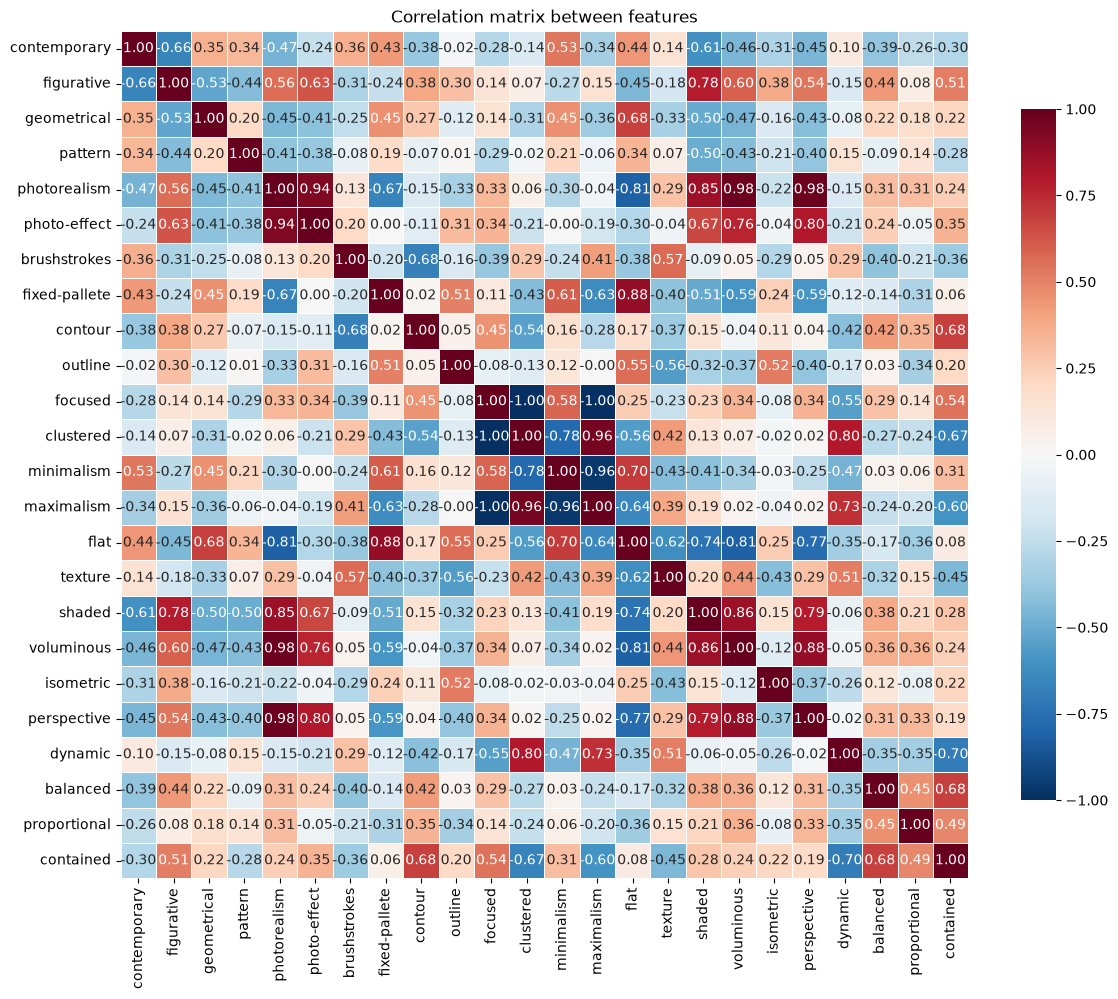


Top 20 most strongly correlated feature pairs:


,f1,f2,corr
185,focused,clustered,-1.000000
187,focused,maximalism,-1.000000
100,photorealism,perspective,0.976624
98,photorealism,voluminous,0.976624
210,minimalism,maximalism,-0.963362
199,clustered,maximalism,0.957020
86,photorealism,photo-effect,0.936586
146,fixed-pallete,flat,0.882087
256,voluminous,perspective,0.877931
248,shaded,voluminous,0.857998


In [4]:
pairs_df, pairs_plt = calculate_correlation_matrix(attributes.iloc[:, 4:-6])
pairs_plt.savefig(root/"output/concept_correlation_matrix_initial.jpg")
pairs_plt.show()
print("\nTop 20 most strongly correlated feature pairs:")
pairs_df.head(20)

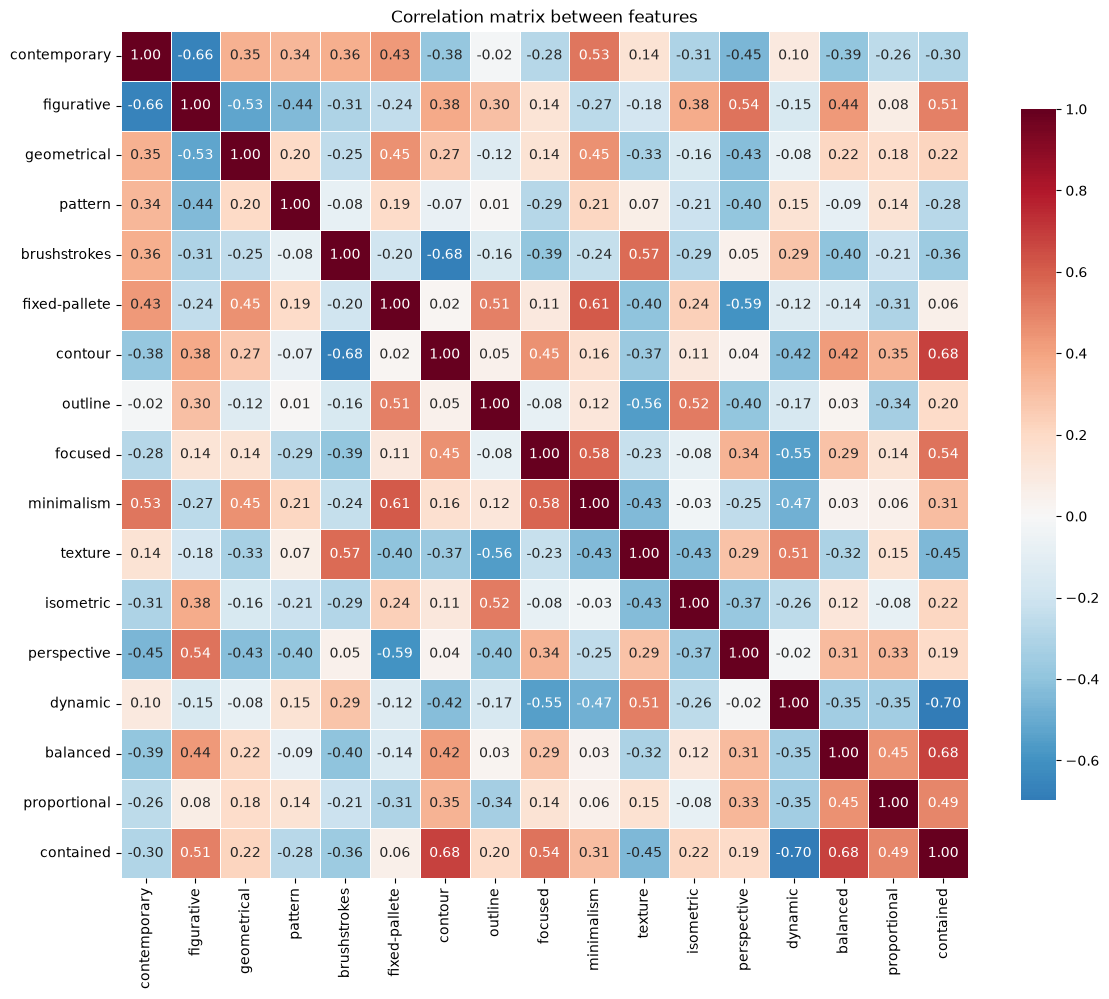


Top 20 most strongly correlated feature pairs:


,f1,f2,corr
132,dynamic,contained,-0.697636
134,balanced,contained,0.682724
90,contour,contained,0.680067
59,brushstrokes,contour,-0.678401
0,contemporary,figurative,-0.660991
73,fixed-pallete,minimalism,0.609232
76,fixed-pallete,perspective,-0.593259
100,focused,minimalism,0.581936
63,brushstrokes,texture,0.568796
93,outline,texture,-0.556038


In [5]:
# drop features based on too high correlations
attributes = attributes.drop(columns=["photorealism", "maximalism", "clustered", "flat", "voluminous", "shaded", "photo-effect"])
attributes.iloc[:, :-6].to_parquet(root/ "data/semantic_concepts.parquet")

pairs_df, pairs_plt = calculate_correlation_matrix(attributes.iloc[:, 4:-6])
pairs_plt.savefig(root / "concept_correlation_matrix_cleaned.jpg")
pairs_plt.show()
print("\nTop 20 most strongly correlated feature pairs:")
pairs_df.head(20)

In [ ]:
breadth_df = attributes[attributes['breadth'].notna()]
depth_df = attributes[attributes['depth'].notna()]
breadth, depth = {}, {}

breadth['y_all'] = breadth_df.iloc[:, :3]
breadth['y'] = breadth['y_all'].iloc[:, 2].cat.codes # abstract = 0, concrete = 1
breadth['X'] = breadth_df.iloc[:, 4:-6] # removes target and on-case-basis features

depth['y_all'] = depth_df.iloc[:, [0,1,3]]
depth['y'] = depth['y_all'].iloc[:, 2].cat.codes # iconic = 0, symbolic = 1
depth['X'] = depth_df.iloc[:, 4:-6] # removes target and on-case-basis features

In dataframes above, the features of painting subject matter (portrait, landscape, still art), and image mode (painting, drawing, photograph) are dropped out because they are not consistant across the body of any style and may only be read in per image from the WikiArt collecton database.

### Concept feature dataset quick analysis

In [ ]:
def compute_consistency_coverage(X: pd.DataFrame):
    """
    X: feature DataFrame (e.g., breadth['X'] or depth['X'])
    Returns a DataFrame with consistency/coverage metrics per feature.
    """
    records = []
    n_styles = len(X)
    
    for col in X.columns:
        vals = X[col]
        n_missing = vals.isna().sum()
        vals_non_missing = vals.dropna()
        
        n_present = (vals_non_missing == 1.0).sum()
        n_absent = (vals_non_missing == 0.0).sum()
        n_indet = (vals_non_missing == 0.5).sum()
        
        denom = n_present + n_absent + n_indet
        if denom > 0:
            consistency = max(n_present, n_absent) / denom
            coverage = denom / n_styles
        else:
            consistency = np.nan
            coverage = 0.0
        
        records.append({
            "feature": col,
            "n_present": n_present,
            "n_absent": n_absent,
            "n_indeterminate": n_indet,
            "n_missing": n_missing,
            "consistency": consistency,
            "coverage": coverage
        })
    
    return pd.DataFrame(records)

In [ ]:
consistency_breadth = compute_consistency_coverage(breadth['X'])
consistency_depth = compute_consistency_coverage(depth['X'])

consistency_breadth.sort_values("consistency", ascending=False)

,feature,n_present,n_absent,n_indeterminate,n_missing,consistency,coverage
7,outline,0,17,1,3,0.944444,0.857143
8,focused,14,1,0,6,0.933333,0.714286
11,isometric,1,17,1,2,0.894737,0.904762
10,texture,17,3,0,1,0.850000,0.952381
3,pattern,3,17,0,1,0.850000,0.952381
2,geometrical,3,16,0,2,0.842105,0.904762
14,balanced,16,3,1,1,0.800000,0.952381
6,contour,13,4,0,4,0.764706,0.809524
15,proportional,11,3,3,4,0.647059,0.809524
0,contemporary,13,8,0,0,0.619048,1.000000


In [9]:
consistency_depth.sort_values("consistency", ascending=False)

,feature,n_present,n_absent,n_indeterminate,n_missing,consistency,coverage
2,geometrical,1,14,0,4,0.933333,0.789474
8,focused,13,2,0,4,0.866667,0.789474
3,pattern,2,15,1,1,0.833333,0.947368
11,isometric,2,13,2,2,0.764706,0.894737
7,outline,2,11,2,4,0.733333,0.789474
10,texture,13,5,0,1,0.722222,0.947368
1,figurative,13,6,0,0,0.684211,1.000000
14,balanced,13,4,2,0,0.684211,1.000000
6,contour,10,4,1,4,0.666667,0.789474
13,dynamic,6,11,1,1,0.611111,0.947368


### Create ML models to analyze and rank feature importances

To deal with the problem of uncovering feature relations we will train and analyse decision tree and random forest models.

In [10]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

In [ ]:
def fit_full_models(X: pd.DataFrame, y: pd.Series, axis_name: str,
                    tree_max_depth: int = 6,
                    rf_n_estimators: int = 300,
                    rf_random_state: int = 0):
    """
    Fit a decision tree and random forest on the FULL data (no train/test split).
    X: feature DataFrame (breadth['X'] or depth['X'])
    y: binary Series (breadth['y'] or depth['y'])
    axis_name: label for logging ('breadth' or 'depth')
    """
    y = y.astype(int)

    # Pipelines with imputation for any NaNs in concept columns
    tree_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("clf", DecisionTreeClassifier(
            max_depth=tree_max_depth,
            random_state=0
        ))
    ])

    rf_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("clf", RandomForestClassifier(
            n_estimators=rf_n_estimators,
            random_state=rf_random_state,
            n_jobs=-1
        ))
    ])

    # Fit on all data
    tree_pipe.fit(X, y)
    rf_pipe.fit(X, y)

    # Feature importances
    tree_clf = tree_pipe.named_steps["clf"]
    rf_clf = rf_pipe.named_steps["clf"]

    feat_imp = pd.DataFrame({
        "feature": X.columns,
        "tree_importance": tree_clf.feature_importances_,
        "rf_importance": rf_clf.feature_importances_
    }).sort_values("rf_importance", ascending=False)

    print(f"\n=== Full-data feature importances for {axis_name.upper()} ===")
    print(feat_imp.head(15))

    return feat_imp, tree_pipe, rf_pipe

In [ ]:
feat_imp_breadth, tree_full_breadth, rf_full_breadth = fit_full_models(
    breadth['X'], breadth['y'], axis_name="breadth"
)

feat_imp_depth, tree_full_depth, rf_full_depth = fit_full_models(
    depth['X'], depth['y'], axis_name="depth"
)


=== Full-data feature importances for BREATH ===
          feature  tree_importance  rf_importance
12    perspective         0.179487       0.331238
1      figurative         0.820513       0.263722
0    contemporary         0.000000       0.067878
14       balanced         0.000000       0.057622
2     geometrical         0.000000       0.049030
3         pattern         0.000000       0.037948
5   fixed-pallete         0.000000       0.037615
15   proportional         0.000000       0.029043
4    brushstrokes         0.000000       0.024759
9      minimalism         0.000000       0.023916
13        dynamic         0.000000       0.022265
16      contained         0.000000       0.017918
6         contour         0.000000       0.013353
11      isometric         0.000000       0.011407
8         focused         0.000000       0.008791

=== Full-data feature importances for DEPTH ===
          feature  tree_importance  rf_importance
10        texture         0.491071       0.144166
0

#### Compute signs for each feature to see what it contirubutes to

In [13]:
def compute_signs(X: pd.DataFrame, y: pd.Series):
    y = y.astype(int)
    records = []
    for col in X.columns:
        vals = X[col]
        mask = vals.notna()
        vals_masked = vals[mask]
        y_masked = y[mask]
        
        mean_0 = vals_masked[y_masked == 0].mean() if (y_masked == 0).any() else np.nan
        mean_1 = vals_masked[y_masked == 1].mean() if (y_masked == 1).any() else np.nan
        
        # sign > 0 means higher in class 1 (concrete/symbolic), sign < 0 means higher in class 0
        diff = (mean_1 or 0) - (mean_0 or 0)
        sign = np.sign(diff) if not np.isnan(diff) else np.nan
        
        records.append({
            "feature": col,
            "mean_val_target0": mean_0,
            "mean_val_target1": mean_1,
            "mean_val_diff": mean_0 - mean_1,
            "sign": sign
        })
    
    return pd.DataFrame(records)

In [ ]:
signs_breadth = compute_signs(breadth['X'], breadth['y'])
signs_depth = compute_signs(depth['X'], depth['y'])

#### Interpretation:

- Large positive diff → concept tends to be higher in class 1 (concrete or symbolic).
- Large negative diff → concept tends to be higher in class 0 (abstract or iconic).
- Very small diff or inconsistent means → concept is weak or potentially contradictory for that axis.

### Create summary of feature consistency, coverage, importances, 

In [ ]:
summary_breadth = consistency_breadth.merge(feat_imp_breadth, on="feature", how="left").merge(signs_breadth, on="feature", how="left")

# -------------------------------------------------------
# future knowledge intervention
tree_column_index = summary_breadth.columns.get_loc("tree_importance")
tree_importances = {"shaded": 1, "voluminous": 1, "perspective": 0.802, "figurative": 0.528}
for feature in tree_importances:
    row_idx = summary_breadth.index[summary_breadth["feature"] == feature].tolist()
    print(feature, row_idx)
    summary_breadth.iloc[row_idx, tree_column_index] = tree_importances[feature]
# -------------------------------------------------------

summary_breadth.to_csv(root / "output/concept_consistency_and_importance_breadth.csv")
print("Summary of feature analysis for breadth axis")
summary_breadth.sort_values("rf_importance", ascending=False)

shaded []
voluminous []
perspective [12]
figurative [1]
Summary of feature analysis for BREATH axis


,feature,n_present,n_absent,n_indeterminate,n_missing,consistency,coverage,tree_importance,rf_importance,mean_val_target0,mean_val_target1,mean_val_diff,sign
12,perspective,10,9,1,1,0.500000,0.952381,0.802,0.331238,0.000000,0.875000,-0.875000,1.0
1,figurative,12,9,0,0,0.571429,1.000000,0.528,0.263722,0.000000,0.923077,-0.923077,1.0
0,contemporary,13,8,0,0,0.619048,1.000000,0.000,0.067878,1.000000,0.384615,0.615385,-1.0
14,balanced,16,3,1,1,0.800000,0.952381,0.000,0.057622,0.571429,0.961538,-0.390110,1.0
2,geometrical,3,16,0,2,0.842105,0.904762,0.000,0.049030,0.428571,0.000000,0.428571,-1.0
3,pattern,3,17,0,1,0.850000,0.952381,0.000,0.037948,0.375000,0.000000,0.375000,-1.0
5,fixed-pallete,8,10,1,2,0.526316,0.904762,0.000,0.037615,0.714286,0.291667,0.422619,-1.0
15,proportional,11,3,3,4,0.647059,0.809524,0.000,0.029043,0.600000,0.791667,-0.191667,1.0
4,brushstrokes,9,9,0,3,0.500000,0.857143,0.000,0.024759,0.666667,0.416667,0.250000,-1.0
9,minimalism,7,7,2,5,0.437500,0.761905,0.000,0.023916,0.666667,0.400000,0.266667,-1.0


In [16]:
summary_depth = consistency_depth.merge(feat_imp_depth, on="feature", how="left").merge(signs_depth, on="feature", how="left")
summary_depth.to_csv(root / "output/concept_consistency_and_importance_depth.csv")
print("Summary of feature analysis for DEPTH axis")
summary_depth.sort_values("rf_importance", ascending=False)

Summary of feature analysis for DEPTH axis


,feature,n_present,n_absent,n_indeterminate,n_missing,consistency,coverage,tree_importance,rf_importance,mean_val_target0,mean_val_target1,mean_val_diff,sign
10,texture,13,5,0,1,0.722222,0.947368,0.491071,0.144166,1.000000,0.285714,0.714286,-1.0
0,contemporary,11,7,1,0,0.578947,1.000000,0.149476,0.122929,0.818182,0.312500,0.505682,-1.0
9,minimalism,6,6,3,4,0.400000,0.789474,0.107955,0.120631,0.454545,0.625000,-0.170455,1.0
16,contained,9,8,1,1,0.500000,0.947368,0.000000,0.097249,0.318182,0.857143,-0.538961,1.0
4,brushstrokes,9,8,0,2,0.529412,0.894737,0.000000,0.095609,0.818182,0.000000,0.818182,-1.0
14,balanced,13,4,2,0,0.684211,1.000000,0.071970,0.090419,0.545455,1.000000,-0.454545,1.0
15,proportional,8,6,4,1,0.444444,0.947368,0.035985,0.051330,0.550000,0.562500,-0.012500,1.0
6,contour,10,4,1,4,0.666667,0.789474,0.000000,0.046195,0.500000,1.000000,-0.500000,1.0
12,perspective,8,9,1,1,0.500000,0.947368,0.000000,0.043935,0.500000,0.428571,0.071429,-1.0
5,fixed-pallete,9,8,1,1,0.500000,0.947368,0.000000,0.043150,0.450000,0.625000,-0.175000,1.0


In [ ]:
breadth_features = pd.read_csv("output/concept_consistency_and_importance_breadth.csv")
depth_features = pd.read_csv("output/concept_consistency_and_importance_depth.csv")

breadth_features["axis"] = "breadth"
depth_features["axis"] = "depth"

column_selection = ["axis", "feature",  "coverage", "consistency", "mean_val_target0", "mean_val_target1", "sign", "rf_importance"]

breadth_features_cleaned = breadth_features[column_selection].sort_values("rf_importance", ascending=False)
depth_features_cleaned = depth_features[column_selection].sort_values("rf_importance", ascending=False)

all_features = pd.concat([breadth_features_cleaned.head(6), depth_features_cleaned.head(6)], ignore_index=True)
all_features = all_features.rename(columns={"mean_val_target0": "abstract/iconic", "mean_val_target1": "concrete/symbolic"})
all_features.to_csv("output/concept_consistency_and_importance_top.csv")
all_features

### Extract full-data decision-tree rules

In [17]:
from sklearn.tree import _tree

def extract_rules_from_tree_full(tree_clf, feature_names, min_styles_leaf=1):
    """
    Extract leaf-level rules from a fitted DecisionTreeClassifier.
    Returns a list of dicts with conditions, style count, and class distribution.
    """
    tree = tree_clf.tree_
    rules = []

    def recurse(node, conditions):
        if tree.feature[node] != _tree.TREE_UNDEFINED:
            feat_idx = tree.feature[node]
            threshold = tree.threshold[node]
            feat_name = feature_names[feat_idx]

            left_conditions = conditions + [(feat_name, "<=", threshold)]
            right_conditions = conditions + [(feat_name, ">", threshold)]

            recurse(tree.children_left[node], left_conditions)
            recurse(tree.children_right[node], right_conditions)
        else:
            value = tree.value[node][0]  # [count_class0, count_class1]
            total = value.sum()
            if total < min_styles_leaf:
                return

            prob_class1 = float(value[1] / total) if total > 0 else 0.0

            rules.append({
                "conditions": conditions,
                "n_styles": int(total),
                "prob_class1": prob_class1,
                "counts": value.tolist()
            })

    recurse(0, [])
    return rules

In [ ]:
tree_clf_breadth = tree_full_breadth.named_steps["clf"]
feature_names_breadth = list(breadth['X'].columns)

breadth_rules = extract_rules_from_tree_full(tree_clf_breadth, feature_names_breadth)

# Sort by how far prob_class1 is from 0.5 (purity) and by support
breadth_rules_sorted = sorted(
    breadth_rules,
    key=lambda r: (abs(r["prob_class1"] - 0.5), r["n_styles"]),
    reverse=True
)

print(f"\nNumber of leaf rules for breadth: {len(breadth_rules_sorted)}")
for r in breadth_rules_sorted[:10]:
    print("Conditions:")
    for cond in r["conditions"]:
        print("   ", cond[0], cond[1], cond[2])
    print("n_styles:", r["n_styles"], "prob_class1:", r["prob_class1"], "counts:", r["counts"])
    print("------")


Number of leaf rules for BREATH: 3
Conditions:
    figurative <= 0.5
    perspective <= 0.5
n_styles: 1 prob_class1: 0.0 counts: [1.0, 0.0]
------
Conditions:
    figurative <= 0.5
    perspective > 0.5
n_styles: 1 prob_class1: 1.0 counts: [0.0, 1.0]
------
Conditions:
    figurative > 0.5
n_styles: 1 prob_class1: 1.0 counts: [0.0, 1.0]
------


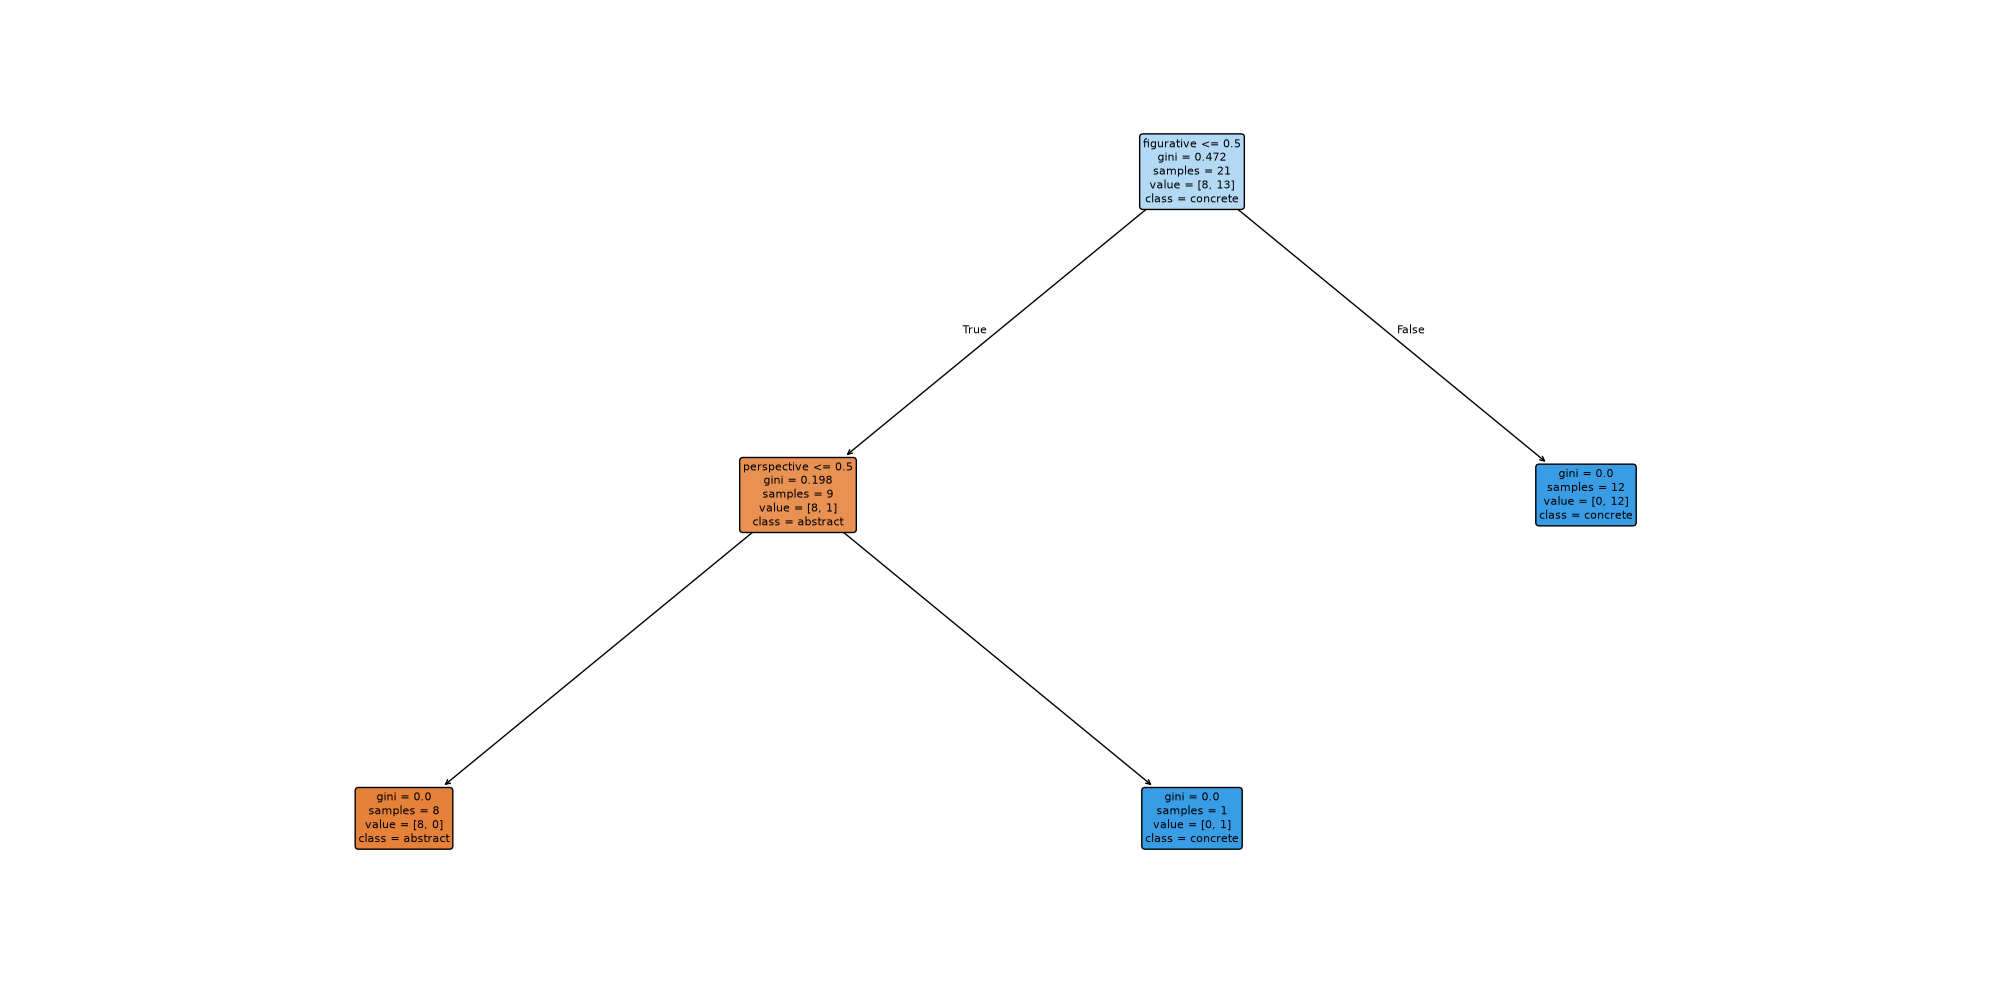

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree


plt.figure(figsize=(20, 10))
plot_tree(
    tree_clf_breadth,
    feature_names=feature_names_breadth,
    class_names=["abstract", "concrete"],  # adjust if needed
    filled=True,
    rounded=True,
    fontsize=8
)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.tree import export_graphviz
import graphviz

tree_clf_breadth = tree_full_breadth.named_steps["clf"]
feature_names_breadth = list(breadth['X'].columns)

dot_data = export_graphviz(
    tree_clf_breadth,
    out_file=None,
    feature_names=feature_names_breadth,
    class_names=["abstract", "concrete"],
    filled=True,
    rounded=True,
    special_characters=True
)

graph = graphviz.Source(dot_data)
graph.render(root / "output/breadth_tree", format="png")  # saves breadth_tree.png

'output/breath_tree.png'

In [21]:
tree_clf_depth = tree_full_depth.named_steps["clf"]
feature_names_depth = list(depth['X'].columns)

depth_rules = extract_rules_from_tree_full(tree_clf_depth, feature_names_depth)

depth_rules_sorted = sorted(
    depth_rules,
    key=lambda r: (abs(r["prob_class1"] - 0.5), r["n_styles"]),
    reverse=True
)

print(f"\nNumber of leaf rules for DEPTH: {len(depth_rules_sorted)}")
for r in depth_rules_sorted[:10]:
    print("Conditions:")
    for cond in r["conditions"]:
        print("   ", cond[0], cond[1], cond[2])
    print("n_styles:", r["n_styles"], "prob_class1:", r["prob_class1"], "counts:", r["counts"])
    print("------")


Number of leaf rules for DEPTH: 7
Conditions:
    texture <= 0.5
n_styles: 1 prob_class1: 1.0 counts: [0.0, 1.0]
------
Conditions:
    texture > 0.5
    geometrical <= 0.5
    contemporary <= 0.5
    balanced <= 0.75
n_styles: 1 prob_class1: 0.0 counts: [1.0, 0.0]
------
Conditions:
    texture > 0.5
    geometrical <= 0.5
    contemporary <= 0.5
    balanced > 0.75
    proportional <= 0.5
n_styles: 1 prob_class1: 1.0 counts: [0.0, 1.0]
------
Conditions:
    texture > 0.5
    geometrical <= 0.5
    contemporary <= 0.5
    balanced > 0.75
    proportional > 0.5
    minimalism <= 0.25
n_styles: 1 prob_class1: 0.0 counts: [1.0, 0.0]
------
Conditions:
    texture > 0.5
    geometrical <= 0.5
    contemporary <= 0.5
    balanced > 0.75
    proportional > 0.5
    minimalism > 0.25
n_styles: 1 prob_class1: 1.0 counts: [0.0, 1.0]
------
Conditions:
    texture > 0.5
    geometrical <= 0.5
    contemporary > 0.5
n_styles: 1 prob_class1: 0.0 counts: [1.0, 0.0]
------
Conditions:
    texture 

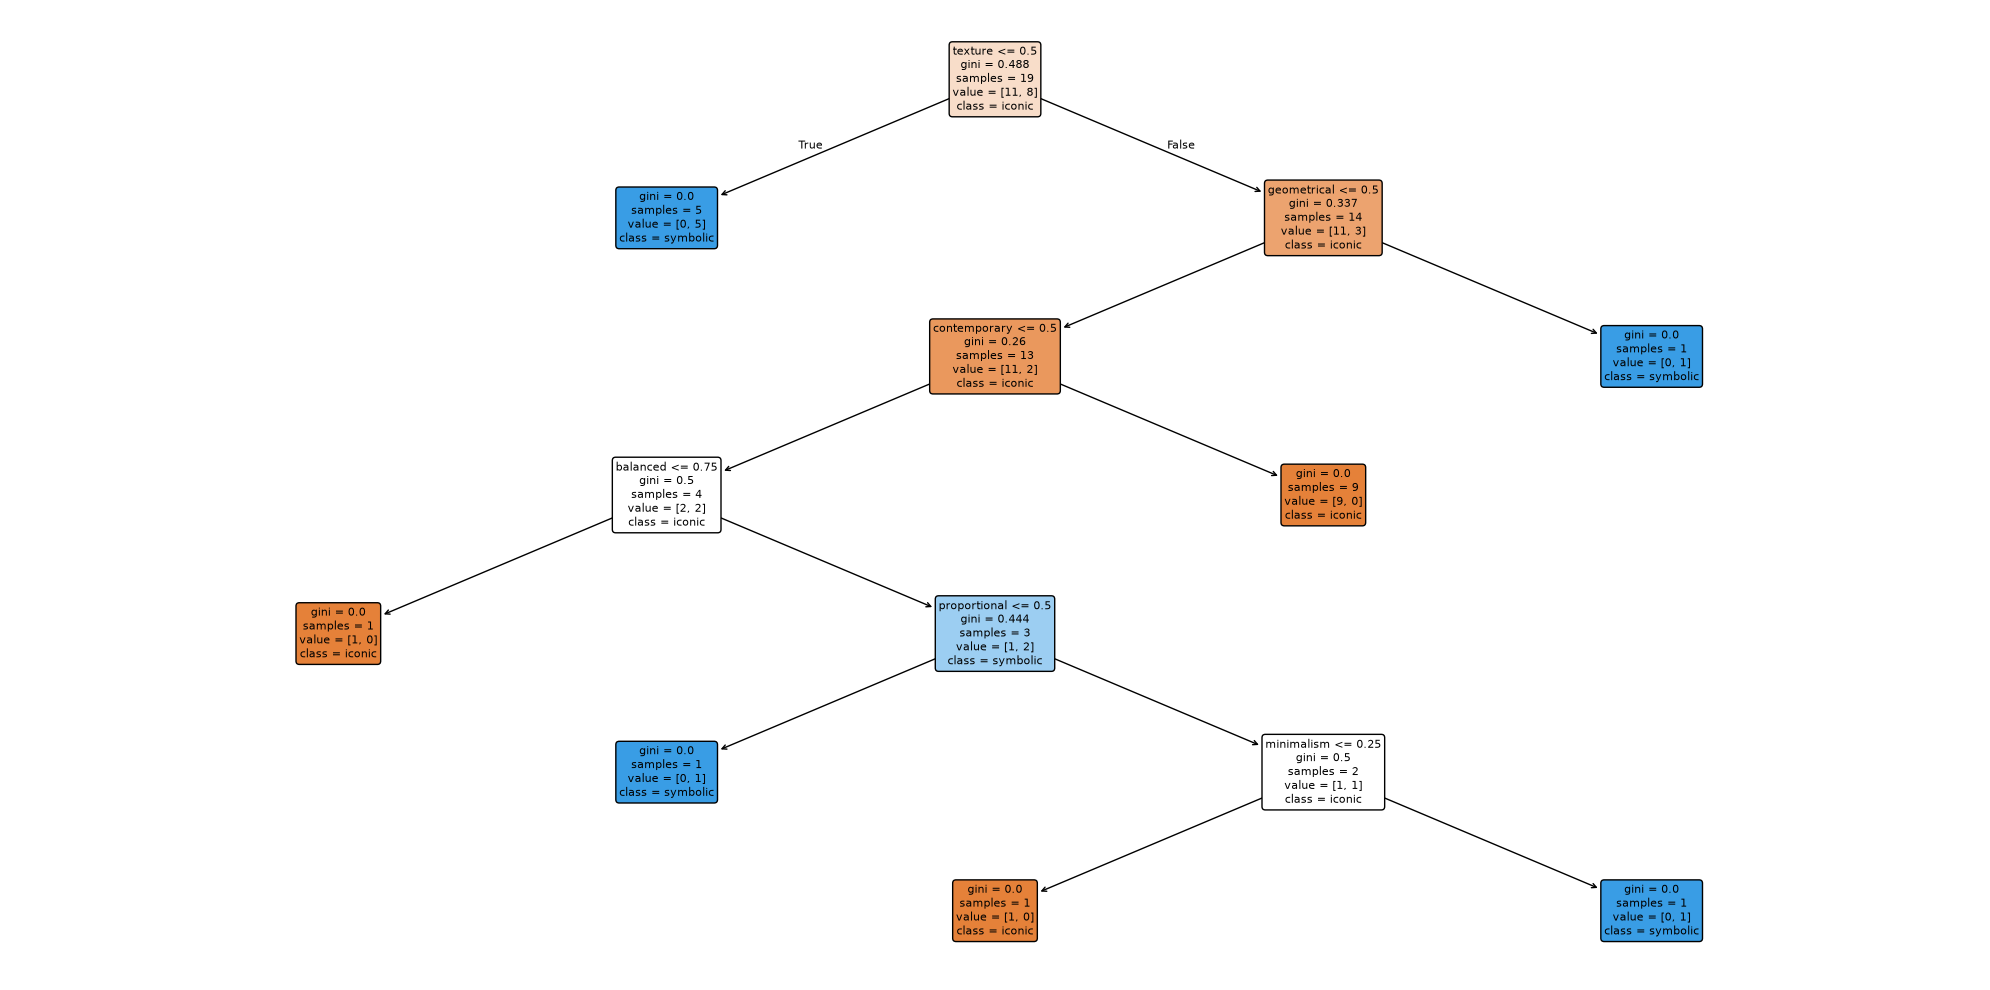

In [22]:
tree_clf_depth = tree_full_depth.named_steps["clf"]
feature_names_depth = list(depth['X'].columns)

plt.figure(figsize=(20, 10))
plot_tree(
    tree_clf_depth,
    feature_names=feature_names_depth,
    class_names=["iconic", "symbolic"],
    filled=True,
    rounded=True,
    fontsize=8
)
plt.tight_layout()
plt.show()

In [23]:
tree_clf_depth = tree_full_depth.named_steps["clf"]
feature_names_depth = list(depth['X'].columns)

dot_data = export_graphviz(
    tree_clf_depth,
    out_file=None,
    feature_names=feature_names_depth,
    class_names=["iconic", "symbolic"],
    filled=True,
    rounded=True,
    special_characters=True
)

graph = graphviz.Source(dot_data)
graph.render(root / "output/depth_tree", format="png")  # saves depth_tree.png

'output/depth_tree.png'

### Pairwise interactions

In [24]:
from itertools import combinations
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier

def pairwise_interactions(X, y, max_depth=3):
    results = []
    features = list(X.columns)

    for fi, fj in combinations(features, 2):
        X_pair = X[[fi, fj]]
        clf_pair = DecisionTreeClassifier(max_depth=max_depth, random_state=0)
        score_pair = cross_val_score(clf_pair, X_pair, y, cv=3).mean()

        # Single-feature baselines
        clf_i = DecisionTreeClassifier(max_depth=max_depth, random_state=0)
        score_i = cross_val_score(clf_i, X[[fi]], y, cv=3).mean()

        clf_j = DecisionTreeClassifier(max_depth=max_depth, random_state=0)
        score_j = cross_val_score(clf_j, X[[fj]], y, cv=3).mean()

        best_single = max(score_i, score_j)
        results.append({
            "f1": fi,
            "f2": fj,
            "score_pair": score_pair,
            "score_f1": score_i,
            "score_f2": score_j,
            "gain_over_best_single": score_pair - best_single
        })

    return pd.DataFrame(results)

In [ ]:
pairs_breadth = pairwise_interactions(breadth['X'], breadth['y'])
pairs_depth = pairwise_interactions(depth['X'], depth['y'])

In [ ]:
print("\nTop interacting pairs for breadth:")
pairs_breadth.sort_values("gain_over_best_single", ascending=False).head(20)


Top interacting pairs for BREATH:


,f1,f2,score_pair,score_f1,score_f2,gain_over_best_single
14,contemporary,proportional,0.904762,0.761905,0.761905,0.142857
102,focused,isometric,0.666667,0.571429,0.523810,0.095238
115,texture,isometric,0.619048,0.523810,0.523810,0.095238
100,focused,minimalism,0.666667,0.571429,0.333333,0.095238
56,pattern,proportional,0.857143,0.761905,0.761905,0.095238
109,minimalism,isometric,0.619048,0.333333,0.523810,0.095238
94,outline,isometric,0.714286,0.666667,0.523810,0.047619
55,pattern,balanced,0.809524,0.761905,0.714286,0.047619
48,pattern,outline,0.809524,0.761905,0.666667,0.047619
66,brushstrokes,dynamic,0.666667,0.476190,0.619048,0.047619


In [27]:
print("\nTop interacting pairs for DEPTH:")
pairs_depth.sort_values("gain_over_best_single", ascending=False).head(20)


Top interacting pairs for DEPTH:


,f1,f2,score_pair,score_f1,score_f2,gain_over_best_single
37,geometrical,minimalism,0.841270,0.682540,0.785714,0.055556
22,figurative,focused,0.579365,0.523810,0.523810,0.055556
41,geometrical,dynamic,0.730159,0.682540,0.626984,0.047619
16,figurative,geometrical,0.730159,0.523810,0.682540,0.047619
108,minimalism,texture,0.888889,0.785714,0.841270,0.047619
88,contour,balanced,0.793651,0.634921,0.746032,0.047619
0,contemporary,figurative,0.793651,0.793651,0.523810,0.000000
2,contemporary,pattern,0.793651,0.793651,0.579365,0.000000
95,outline,perspective,0.785714,0.785714,0.523810,0.000000
104,focused,dynamic,0.626984,0.523810,0.626984,0.000000


# SHAP values

In [28]:
import shap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

/home/trpquo/miniforge-pypy3/envs/fastai/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Global importance: mean |SHAP| per feature

In [29]:
from settings import get_class_names_per_axis
class_names = get_class_names_per_axis()

feature_perturbation_mode=["tree_path_dependent","interventional"][0] 

def compute_shap_values(rf_pipe, X, axis):
    """
    rf_pipe: fitted Pipeline with RandomForestClassifier as .named_steps["clf"]
    X: feature DataFrame used for fitting
    Returns shap_values for class 1 and aligned feature names.
    """
    rf_clf = rf_pipe.named_steps["clf"]
    feature_names = list(X.columns)
    
    explainer = shap.TreeExplainer(
        rf_clf, 
        X,
        feature_perturbation=feature_perturbation_mode
        )
    shap_raw = explainer.shap_values(X)

    # shap_raw shape: (n_samples, n_features, n_classes)
    # We want class 1 (index 1) along the last axis
    if shap_raw.ndim == 3:
        shap_class1 = shap_raw[:, :, 1]
    else:
        # Fallback for other setups
        shap_class1 = shap_raw
    
    # shap_class1 should be (n_samples, n_features)
    assert shap_class1.shape == (X.shape[0], len(feature_names)), (
        f"Expected shape ({X.shape[0]}, {len(feature_names)}), "
        f"got {shap_class1.shape}"
    )
    
    return shap_class1, feature_names

In [ ]:
import numpy as np

rf_clf_breadth = rf_full_breadth.named_steps["clf"]
explainer = shap.TreeExplainer(rf_clf_breadth)

X_breadth = breadth['X']
shap_raw = explainer.shap_values(X_breadth)  # (n, f, 2)
shap_class0 = shap_raw[:, :, 0]
shap_class1 = shap_raw[:, :, 1]

# Base value (expected model output)
base_value_class0 = explainer.expected_value[0]
base_value_class1 = explainer.expected_value[1]

# Pick a few samples to check
for i in [0, 5, 10]:
    x_shap0 = base_value_class0 + shap_class0[i, :].sum()
    x_shap1 = base_value_class1 + shap_class1[i, :].sum()
    
    proba = rf_clf_breadth.predict_proba(X_breadth.iloc[[i]])[0]
    
    print(f"Sample {i}:")
    print("  SHAP-reconstructed class 0 output:", x_shap0)
    print("  SHAP-reconstructed class 1 output:", x_shap1)
    print("  Model predicted probabilities:", proba)
    print()

/home/trpquo/miniforge-pypy3/envs/fastai/lib/python3.12/site-packages/sklearn/utils/validation.py:2820: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/home/trpquo/miniforge-pypy3/envs/fastai/lib/python3.12/site-packages/sklearn/utils/validation.py:2820: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/home/trpquo/miniforge-pypy3/envs/fastai/lib/python3.12/site-packages/sklearn/utils/validation.py:2820: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


Sample 0:
  SHAP-reconstructed class 0 output: 0.9233333333333332
  SHAP-reconstructed class 1 output: 0.07666666666666722
  Model predicted probabilities: [0.92333333 0.07666667]

Sample 5:
  SHAP-reconstructed class 0 output: 0.9166666666666664
  SHAP-reconstructed class 1 output: 0.08333333333333415
  Model predicted probabilities: [0.91666667 0.08333333]

Sample 10:
  SHAP-reconstructed class 0 output: -2.7755575615628914e-16
  SHAP-reconstructed class 1 output: 1.0000000000000004
  Model predicted probabilities: [0. 1.]



In [ ]:
shap_breadth, feat_names_breadth = compute_shap_values(rf_full_breadth, breadth['X'], axis="breadth")
shap_depth, feat_names_depth = compute_shap_values(rf_full_depth, depth['X'], axis="depth")

print("shap_breadth shape:", shap_breadth.shape)
print("len(feat_names_breadth):", len(feat_names_breadth))

shap_breath shape: (21, 17)
len(feat_names_breath): 17


In [ ]:
print(pd.DataFrame({"feature": feat_names_breadth, "shap_values": shap_breadth.mean(axis=0)}))


          feature  shap_values
0    contemporary    -0.004096
1      figurative     0.002132
2     geometrical     0.003456
3         pattern     0.002389
4    brushstrokes    -0.000752
5   fixed-pallete     0.000430
6         contour     0.000127
7         outline    -0.000190
8         focused     0.000450
9      minimalism    -0.000171
10        texture     0.000251
11      isometric    -0.000497
12    perspective    -0.006336
13        dynamic     0.000656
14       balanced     0.003200
15   proportional    -0.000196
16      contained    -0.000854


In [33]:
print(pd.DataFrame({"feature": feat_names_depth, "shap_values": shap_depth.mean(axis=0)}))


          feature  shap_values
0    contemporary    -0.001933
1      figurative     0.001406
2     geometrical    -0.001571
3         pattern     0.000612
4    brushstrokes    -0.002951
5   fixed-pallete    -0.001934
6         contour     0.003085
7         outline    -0.001043
8         focused     0.000562
9      minimalism     0.006436
10        texture    -0.008009
11      isometric    -0.001907
12    perspective     0.001971
13        dynamic     0.002170
14       balanced     0.003759
15   proportional    -0.000167
16      contained    -0.000485


In [34]:
def plot_shap_global_importance(shap_values, feature_names, title):
    # Mean absolute SHAP value per feature
    shap_sum = np.abs(shap_values).mean(axis=0)
    importance_df = pd.DataFrame({
        "feature": feature_names,
        "mean_abs_shap": shap_sum
    }).sort_values("mean_abs_shap", ascending=True)  # ascending for horizontal bar

    plt.figure(figsize=(8, max(4, 0.25 * len(feature_names))))
    plt.barh(importance_df["feature"], importance_df["mean_abs_shap"])
    plt.xlabel("Mean |SHAP value| (class 1)")
    plt.title(title)
    plt.tight_layout()
    return plt

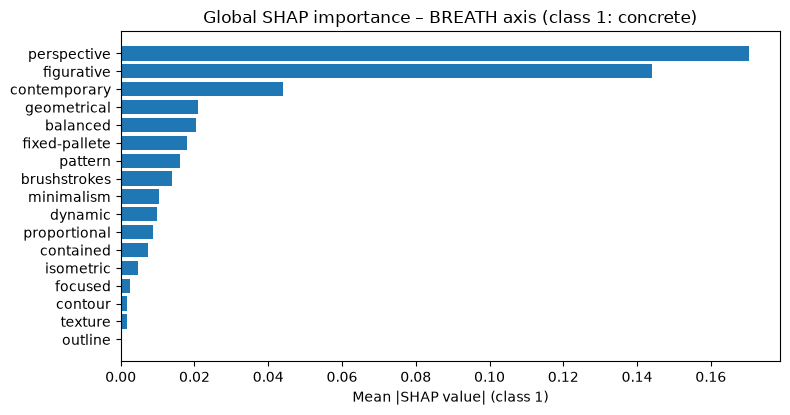

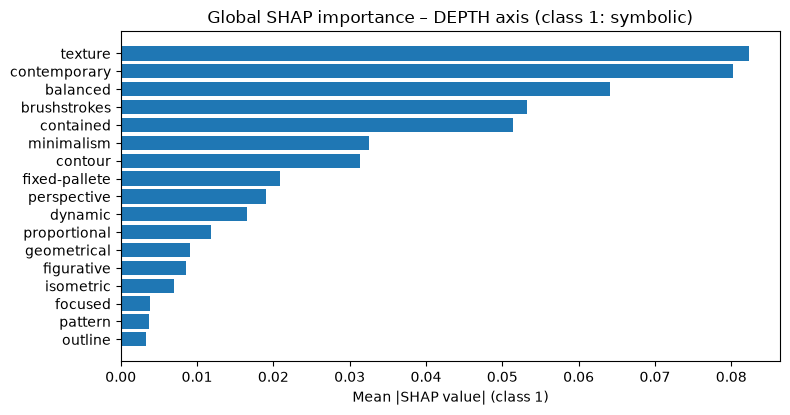

In [ ]:
shap_global_plot_breadth = plot_shap_global_importance(
    shap_breadth, feat_names_breadth,
    "Global SHAP importance – breadth axis (class 1: concrete)"
)
shap_global_plot_breadth.savefig(root / f"output/shap_global_plot_breadth_{feature_perturbation_mode}.jpg")
shap_global_plot_breadth.show()

shap_global_plot_depth = plot_shap_global_importance(
    shap_depth, feat_names_depth,
    "Global SHAP importance – DEPTH axis (class 1: symbolic)"
)
shap_global_plot_depth.savefig(root / f"output/shap_global_plot_depth_{feature_perturbation_mode}.jpg")
shap_global_plot_depth.show()

In [36]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def plot_shap_signed_importance(shap_values, feature_names, title):
    """
    shap_values: (n_samples, n_features) array of SHAP values for class 1
    feature_names: list of feature names (length n_features)
    title: plot title
    """
    # Mean SHAP value per feature (signed)
    mean_shap = shap_values.mean(axis=0)
    
    df = pd.DataFrame({
        "feature": feature_names,
        "mean_shap": mean_shap
    }).sort_values("mean_shap", ascending=True)  # ascending for horizontal bar
    
    plt.figure(figsize=(8, max(4, 0.25 * len(feature_names))))
    plt.barh(df["feature"], df["mean_shap"], color="steelblue")
    plt.axvline(0, color="black", linewidth=0.5)
    plt.xlabel("Mean SHAP value")
    plt.title(title)

    ticks = []
    for axis in categories.keys():
        if axis in title.lower():
            ticks = list(categories[axis].keys())
        else:
            print(f"{axis.upper()} is not in {title}")

    plt.xticks(
        [-abs(df["mean_shap"]).max(), 0, abs(df["mean_shap"]).max()],
        [ticks[0].capitalize(), "Neutral", ticks[1].capitalize()]
    )

    plt.tight_layout()
    return plt

DEPTH is not in Signed SHAP importance – BREATH axis


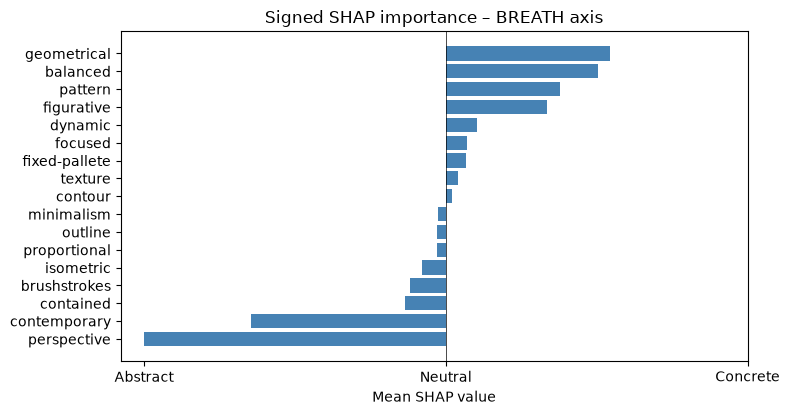

BREATH is not in Signed SHAP importance – DEPTH axis


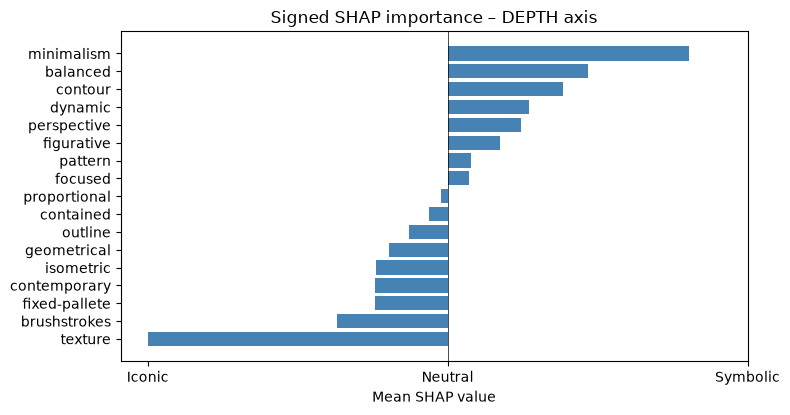

In [ ]:
plot_shap_signed_breadth = plot_shap_signed_importance(
    shap_breadth, feat_names_breadth,
    "Signed SHAP importance – breadth axis"
)
plot_shap_signed_breadth.savefig(root / f"output/shap_global_signed_breadth_{feature_perturbation_mode}.jpg")
plot_shap_signed_breadth.show()

plot_shap_signed_depth = plot_shap_signed_importance(
    shap_depth, feat_names_depth,
    "Signed SHAP importance – DEPTH axis"
)
plot_shap_signed_depth.savefig(root / f"output/shap_global_signed_depth_{feature_perturbation_mode}.jpg")
plot_shap_signed_depth.show()

In [ ]:
rf_clf_breadth = rf_full_breadth.named_steps["clf"]
proba_breadth = rf_clf_breadth.predict_proba(breadth['X'])[:, 1]  # P(concrete)

breadth_pred_check = pd.DataFrame({
    "style": breadth_df["style"],
    "breadth_label": breadth_df["breadth"],
    "p_concrete": proba_breadth
})

print("Average P(concrete) by true breadth label:")
print(breadth_pred_check.groupby("breadth_label")["p_concrete"].mean())

Average P(concrete) by true breath label:
breath_label
abstract    0.077083
concrete    0.939744
Name: p_concrete, dtype: float64


/home/trpquo/miniforge-pypy3/envs/fastai/lib/python3.12/site-packages/sklearn/utils/validation.py:2820: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


In [39]:
import shap
import matplotlib.pyplot as plt

def plot_shap_summary_dot_signed(
    shap_values, X, feature_names, title,
    max_display=15,
    colorbar_label="Feature value"
):
    """
    shap_values: (n_samples, n_features) SHAP values for class 1
    X: feature DataFrame (same rows as shap_values)
    feature_names: list of feature names
    """
    plt.figure(figsize=(10, max(6, 0.3 * len(feature_names))))
    
    shap.summary_plot(
        shap_values,
        features=X,
        feature_names=feature_names,
        max_display=max_display,
        plot_type="dot",
        show=False,
        color_bar_label=colorbar_label
    )
    
    plt.title(title)
    plt.tight_layout()
    return plt
    
    # Optional explanatory text below the plot
    print("Color scale: blue = low feature value, red = high feature value.")
    print("Positive SHAP → pushes prediction toward class 1 (concrete / symbolic).")
    print("Negative SHAP → pushes prediction toward class 0 (abstract / iconic).")

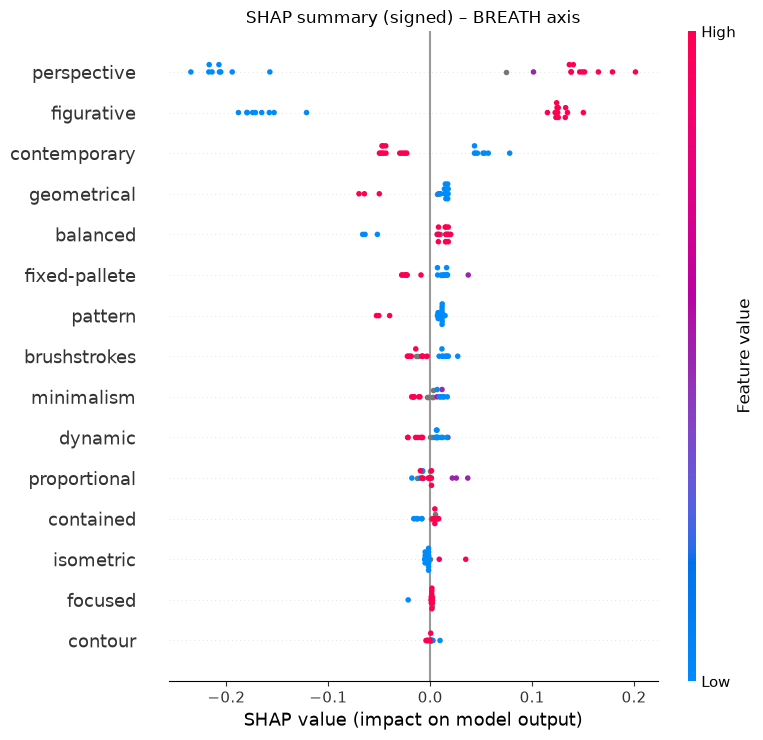

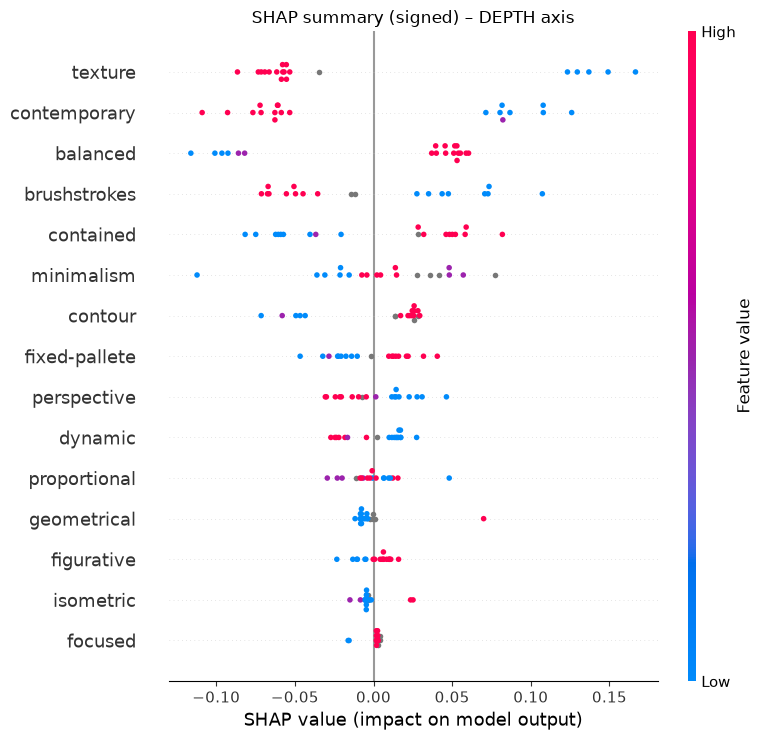

In [ ]:
shap_summary_dot_breadth = plot_shap_summary_dot_signed(
    shap_breadth, breadth['X'], feat_names_breadth,
    "SHAP summary (signed) – breadth axis",
    max_display=15
)
shap_summary_dot_breadth.savefig(root / f"output/shap_summary_dot_breadth_{feature_perturbation_mode}.jpg")
shap_summary_dot_breadth.show()

shap_summary_dot_depth = plot_shap_summary_dot_signed(
    shap_depth, depth['X'], feat_names_depth,
    "SHAP summary (signed) – DEPTH axis",
    max_display=15
)
shap_summary_dot_depth.savefig(root / f"output/shap_summary_dot_depth_{feature_perturbation_mode}.jpg")
shap_summary_dot_depth.show()

### Pairwise SHAP interactions

In [ ]:
def shap_interaction_summary(rf_clf, X: pd.DataFrame, class_index: int = 1):
    """
    rf_clf: fitted sklearn RandomForestClassifier
    X: feature DataFrame (e.g., breadth['X'])
    class_index: 0 or 1 for binary classification
    Returns a DataFrame with average absolute interaction for each pair.
    """
    explainer = shap.TreeExplainer(rf_clf)
    shap_interaction_values = explainer.shap_interaction_values(X)

    # Handle shape differences
    if shap_interaction_values.ndim == 3:
        interaction_matrix = shap_interaction_values
    elif shap_interaction_values.ndim == 4:
        interaction_matrix = shap_interaction_values[..., class_index]
    else:
        raise ValueError(f"Unexpected shape of shap_interaction_values: {shap_interaction_values.shape}")

    n_samples, n_features, _ = interaction_matrix.shape
    feature_names = list(X.columns)

    avg_interaction = np.zeros((n_features, n_features))

    for i in range(n_features):
        for j in range(n_features):
            avg_interaction[i, j] = np.mean(np.abs(interaction_matrix[:, i, j]))

    # Build a table of interactions (only upper triangle to avoid duplicates)
    records = []
    for i in range(n_features):
        for j in range(i+1, n_features):
            records.append({
                "f1": feature_names[i],
                "f2": feature_names[j],
                "avg_abs_interaction": avg_interaction[i, j]
            })

    return pd.DataFrame(records).sort_values("avg_abs_interaction", ascending=False)

In [ ]:
rf_clf_breadth = rf_full_breadth.named_steps["clf"]
interaction_df_breadth = shap_interaction_summary(rf_clf_breadth, breadth['X'], class_index=1)

print("\nTop SHAP interactions for breadth:")
interaction_df_breadth.head(10)


Top SHAP interactions for BREATH:


,f1,f2,avg_abs_interaction
11,contemporary,perspective,0.009746
26,figurative,perspective,0.009049
65,brushstrokes,perspective,0.005204
29,figurative,proportional,0.003838
121,isometric,perspective,0.002954
0,contemporary,figurative,0.002865
28,figurative,balanced,0.002425
20,figurative,contour,0.002419
127,perspective,balanced,0.002162
30,figurative,contained,0.002159


In [43]:
rf_clf_depth = rf_full_depth.named_steps["clf"]
interaction_df_depth = shap_interaction_summary(rf_clf_depth, depth['X'], class_index=1)

print("\nTop SHAP interactions for DEPTH:")
interaction_df_depth.head(10)


Top SHAP interactions for DEPTH:


,f1,f2,avg_abs_interaction
62,brushstrokes,minimalism,0.008679
8,contemporary,minimalism,0.008194
68,brushstrokes,proportional,0.008121
129,perspective,contained,0.005925
114,minimalism,contained,0.005324
113,minimalism,proportional,0.005153
80,fixed-pallete,contained,0.004844
4,contemporary,fixed-pallete,0.004136
88,contour,balanced,0.004105
5,contemporary,contour,0.003510


In [44]:
def shap_interaction_matrix(rf_pipe, X: pd.DataFrame, class_index: int = 1):
    """
    rf_pipe: fitted Pipeline with RandomForest[Classifier|Regressor] as .named_steps["clf"]
    X: feature DataFrame
    class_index: for classification, which class to inspect (0 or 1)
    Returns:
        avg_abs_interaction: (n_features, n_features) array
        feature_names: list of feature names
    """
    rf_clf = rf_pipe.named_steps["clf"]
    explainer = shap.TreeExplainer(rf_clf)
    shap_interaction_values = explainer.shap_interaction_values(X)

    # Handle shape differences
    if shap_interaction_values.ndim == 3:
        # (n_samples, n_features, n_features)
        interaction_matrix = shap_interaction_values
    elif shap_interaction_values.ndim == 4:
        # (n_samples, n_features, n_features, n_classes)
        interaction_matrix = shap_interaction_values[..., class_index]
    else:
        raise ValueError(f"Unexpected shape: {shap_interaction_values.shape}")

    n_features = interaction_matrix.shape[1]
    avg_abs_interaction = np.zeros((n_features, n_features))

    for i in range(n_features):
        for j in range(n_features):
            avg_abs_interaction[i, j] = np.mean(np.abs(interaction_matrix[:, i, j]))

    return avg_abs_interaction, list(X.columns)

In [ ]:
avg_int_breadth, feat_names_breadth = shap_interaction_matrix(
    rf_full_breadth, breadth['X'], class_index=1
)

avg_int_depth, feat_names_depth = shap_interaction_matrix(
    rf_full_depth, depth['X'], class_index=1
)

In [46]:
def plot_shap_interaction_heatmap(avg_abs_interaction, feature_names, vmax=None, title="SHAP interaction heatmap"):
    df_int = pd.DataFrame(
        avg_abs_interaction,
        index=feature_names,
        columns=feature_names
    )

    plt.figure(figsize=(12, 10))
    sns.heatmap(
        df_int,
        annot=False,  # set True if few features
        cmap="viridis",
        vmax=vmax,
        square=True,
        cbar_kws={"label": "Mean |SHAP interaction|"}
    )
    plt.title(title)
    plt.tight_layout()
    return plt

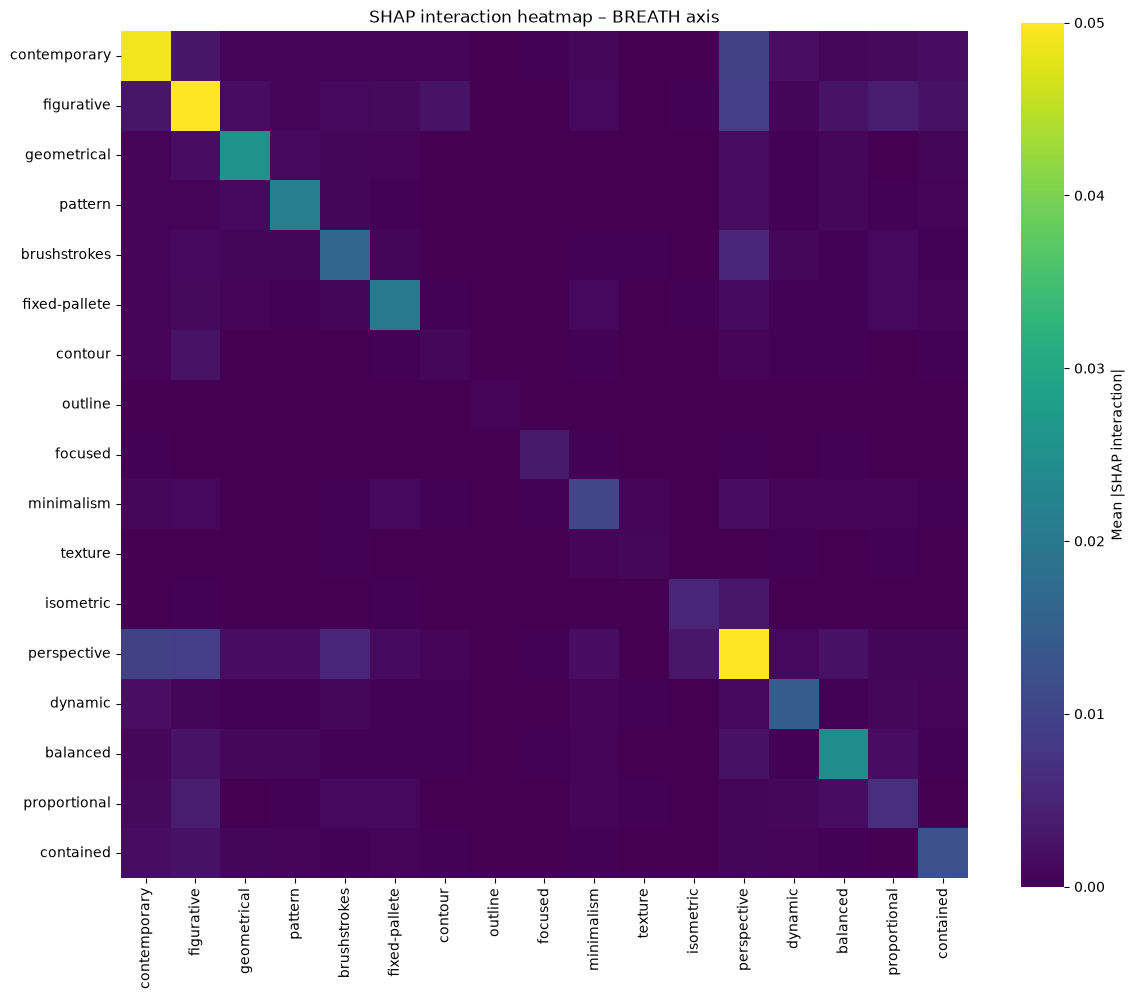

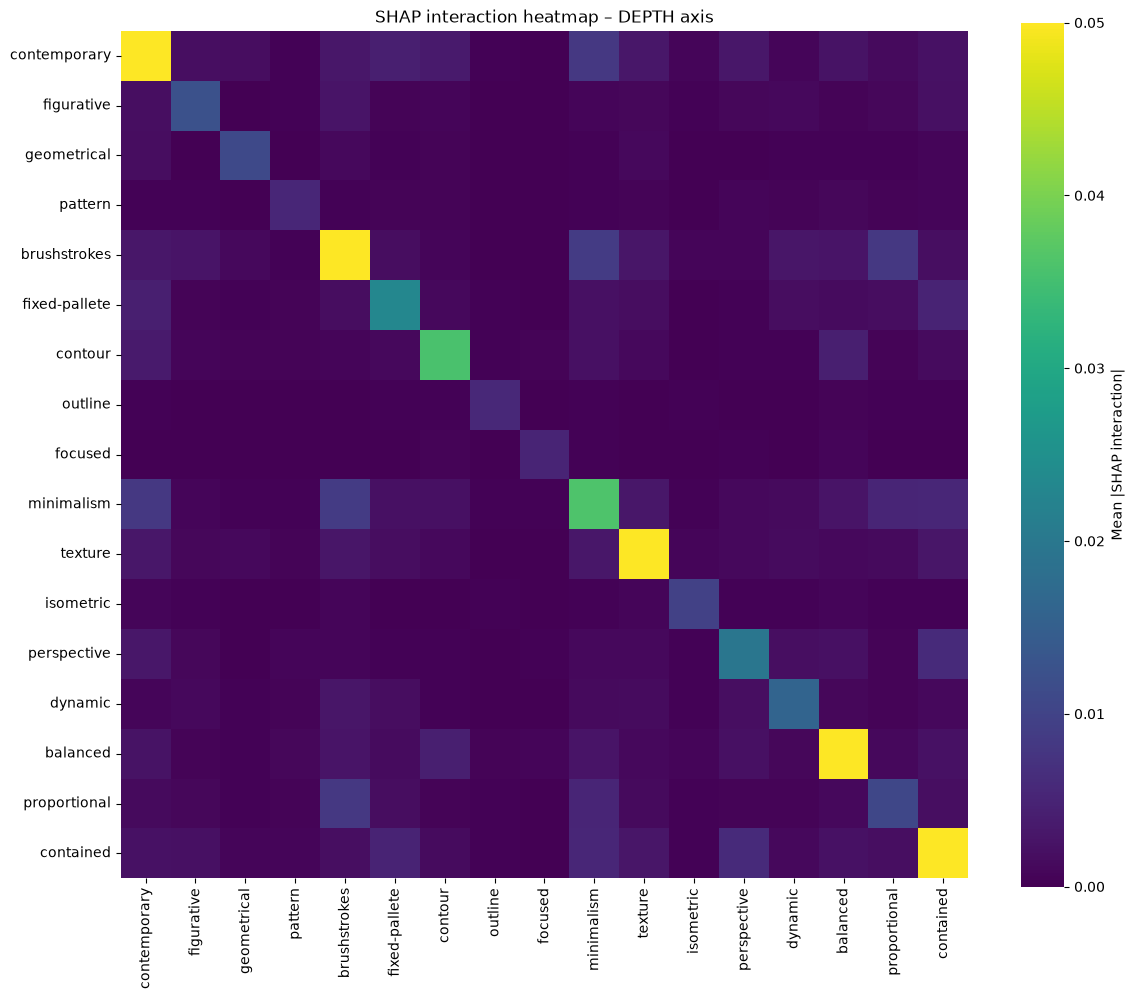

In [ ]:
shap_interaction_plot_breadth = plot_shap_interaction_heatmap(
    avg_int_breadth, feat_names_breadth, vmax=0.05, title="SHAP interaction heatmap – breadth axis"
)
shap_interaction_plot_breadth.savefig(root / f"output/shap_interaction_plot_breadth_{feature_perturbation_mode}.png")
shap_interaction_plot_breadth.show()

shap_interaction_plot_depth = plot_shap_interaction_heatmap(
    avg_int_depth, feat_names_depth, vmax=0.05, title="SHAP interaction heatmap – DEPTH axis"
)
shap_interaction_plot_depth.savefig(root / f"output/shap_interaction_plot_depth_{feature_perturbation_mode}.png")
shap_interaction_plot_depth.show()

In [ ]:
def interaction_ratio(avg_abs_interaction):
    diag = np.diag(avg_abs_interaction)
    off_diag = avg_abs_interaction[np.triu_indices_from(avg_abs_interaction, k=1)]
    return {
        "max_diag": float(np.max(diag)),
        "max_off_diag": float(np.max(off_diag)),
        "median_diag": float(np.median(diag)),
        "median_off_diag": float(np.median(off_diag)),
        "ratio_max_off_to_max_diag": float(np.max(off_diag) / np.max(diag)),
        "ratio_median_off_to_median_diag": float(np.median(off_diag) / np.median(diag)),
    }

print("breadth interaction ratios:", interaction_ratio(avg_int_breadth))
print("Depth interaction ratios:", interaction_ratio(avg_int_depth))

Breath interaction ratios: {'max_diag': 0.1765604287183986, 'max_off_diag': 0.009745546109133212, 'median_diag': 0.014103568387746467, 'median_off_diag': 0.0003261812725928607, 'ratio_max_off_to_max_diag': 0.055196660881905016, 'ratio_median_off_to_median_diag': 0.023127570528622753}
Depth interaction ratios: {'max_diag': 0.08814834978686702, 'max_off_diag': 0.00867935629499069, 'median_diag': 0.019683880757200057, 'median_off_diag': 0.0006432894889282912, 'ratio_max_off_to_max_diag': 0.09846306046541332, 'ratio_median_off_to_median_diag': 0.032681029562373565}


In [49]:
import networkx as nx

def plot_interaction_network(avg_abs_interaction, feature_names, axis_name, threshold=None, top_k=None):
    n = len(feature_names)
    edges = []
    for i in range(n):
        for j in range(i+1, n):
            w = avg_abs_interaction[i, j]
            edges.append((i, j, w))

    # Filter by threshold or top_k
    if threshold is not None:
        edges = [e for e in edges if e[2] >= threshold]
    elif top_k is not None:
        edges = sorted(edges, key=lambda e: e[2], reverse=True)[:top_k]

    G = nx.Graph()
    for i in range(n):
        G.add_node(i, label=feature_names[i])
    for i, j, w in edges:
        G.add_edge(i, j, weight=w)

    pos = nx.spring_layout(G, k=1.5, seed=0)
    plt.figure(figsize=(10, 8))
    nx.draw(
        G, pos,
        labels={i: feature_names[i] for i in range(n)},
        node_size=800,
        node_color="lightblue",
        font_size=8,
        edge_color="gray",
        width=1
    )
    plt.title(f"SHAP interaction network for {axis_name.upper()} (strongest pairs)")
    plt.tight_layout()
    plt.show()

/tmp/ipykernel_93427/677433061.py:35: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


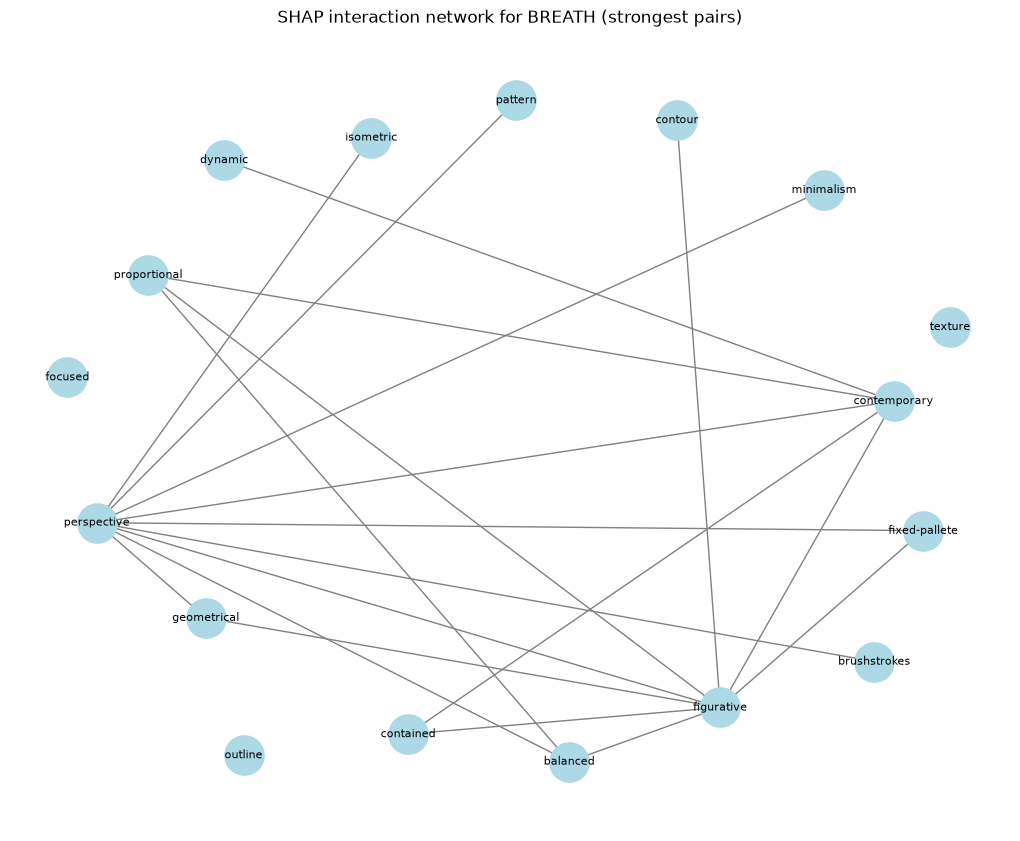

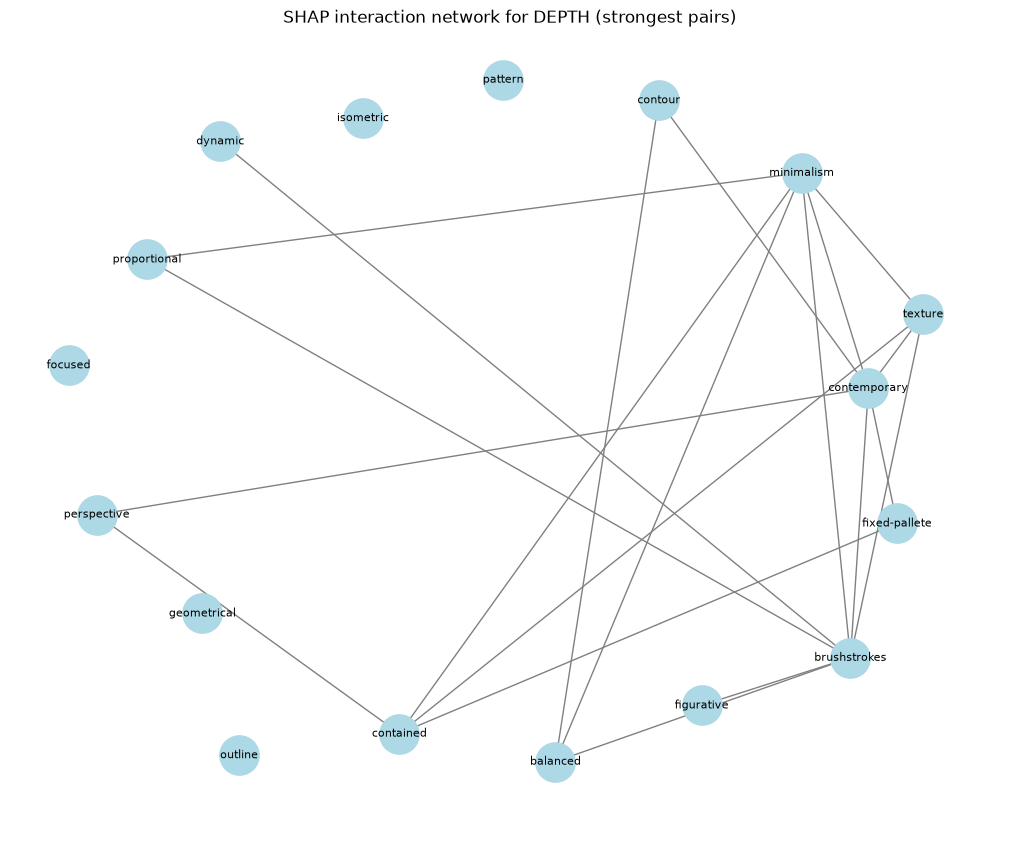

In [ ]:
plot_interaction_network(avg_int_breadth, feat_names_breadth, axis_name="breadth", top_k=20)
plot_interaction_network(avg_int_depth, feat_names_depth, axis_name="depth", top_k=20)

### Info: Detecting concepts that best distinguish styles themselves

In [ ]:
# Select features and target for style
X_styles = attributes.drop(columns=["century", "style", "breadth", "depth"])  # adjust if needed
y_styles = attributes["style"]

style_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("clf", RandomForestClassifier(
        n_estimators=300,
        random_state=0,
        n_jobs=-1
    ))
])

style_pipe.fit(X_styles, y_styles)

rf_style = style_pipe.named_steps["clf"]
style_importance = pd.DataFrame({
    "feature": X_styles.columns,
    "importance": rf_style.feature_importances_
}).sort_values("importance", ascending=False)

print("\nFeatures most important for distinguishing styles:")
style_importance.head(20)

/home/trpquo/miniforge-pypy3/envs/fastai/lib/python3.12/site-packages/sklearn/ensemble/_forest.py:811: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  check_classification_targets(y)
/home/trpquo/miniforge-pypy3/envs/fastai/lib/python3.12/site-packages/sklearn/tree/_classes.py:289: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  check_classification_targets(y)
/home/trpquo/miniforge-pypy3/envs/fastai/lib/python3.12/site-packages/sklearn/tree/_classes.py:289: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  check_classification_targets(y)
/home/trpquo/miniforge-pypy3/envs/fastai/lib/python3.12/site-packages/sklearn/tree/_classes.py:289: UserWarning: Th


Features most important for distinguishing styles:


,feature,importance
9,minimalism,0.124521
5,fixed-pallete,0.086639
17,face-body,0.076668
4,brushstrokes,0.073809
15,proportional,0.067563
12,perspective,0.055089
13,dynamic,0.054997
0,contemporary,0.053603
10,texture,0.053035
16,contained,0.050381


In [52]:
included_styles = []
for axis in categories:
    for category in categories[axis]:
        for style in categories[axis][category]:
            if style not in included_styles:
                included_styles.append(style)

data = pd.read_parquet(f"{root}/data/wikiart_composed.parquet")
data = data[data['style'].isin(included_styles)]
artemis = data[data['artemis'].notna()]
emotions = data[data['emotions'].notna()]
both = pd.merge(artemis, emotions)
data.shape, artemis.shape, emotions.shape, both.shape

((39944, 17), (1738, 17), (2564, 17), (474, 17))

In [53]:
concepts = pd.read_parquet(root/ "data/semantic_concepts.parquet")
concept_labels = concepts.iloc[:, 4:].columns.tolist()
concepts[concept_labels] = concepts[concept_labels].fillna(0.5)
concepts

,century,style,breath,depth,contemporary,figurative,geometrical,pattern,brushstrokes,fixed-pallete,...,outline,focused,minimalism,texture,isometric,perspective,dynamic,balanced,proportional,contained
0,20.5,Hard Edge Painting,abstract,NaN,1.0,0,1.0,0.0,0.0,1.0,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.5,0.5
1,20.0,Concretism,abstract,NaN,1.0,0,1.0,1.0,0.5,1.0,...,0.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,0.5,0.5
2,20.0,Suprematism,abstract,symbolic,1.0,0,1.0,0.0,0.5,1.0,...,0.5,0.5,0.5,0.5,0.0,0.0,0.0,1.0,1.0,1.0
3,20.0,Abstract Art,abstract,NaN,1.0,0,0.0,0.0,1.0,0.5,...,0.0,0.5,0.5,1.0,0.0,0.0,0.5,0.5,0.5,0.5
4,20.0,Abstract Expressionism,abstract,iconic,1.0,0,0.5,0.0,1.0,0.0,...,0.5,0.5,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
5,20.5,Action painting,abstract,iconic,1.0,0,0.0,1.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0
6,15.0,Northern Renaissance,concrete,NaN,0.0,1,0.0,0.0,0.0,0.0,...,0.0,0.5,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0
7,20.0,Hyper-Realism,concrete,iconic,1.0,1,0.0,0.0,0.0,0.0,...,0.0,1.0,1.0,1.0,0.0,1.0,0.5,1.0,1.0,1.0
8,17.0,Tenebrism,concrete,NaN,0.0,1,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0
9,19.0,Academicism,concrete,iconic,0.0,1,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0


In [54]:
data_with_cid = data.reset_index()
conceptualized = data_with_cid.merge(concepts, on='style', how='left')
conceptualized = conceptualized.set_index("contentId")
conceptualized = conceptualized[~conceptualized.index.duplicated(keep="first")]
conceptualized.to_parquet(root/ "data/wikiart_composed_with_concepts.parquet")
conceptualized.columns

Index(['artistName', 'title', 'year', 'style', 'genre', 'photography',
       'artemis', 'emotions', 'Is painting', 'Face/body', 'Rating',
       'artistContentId', 'artistUrl', 'paintingUrl', 'localUrl', 'webUrl',
       'webUrl2', 'century', 'breath', 'depth', 'contemporary', 'figurative',
       'geometrical', 'pattern', 'brushstrokes', 'fixed-pallete', 'contour',
       'outline', 'focused', 'minimalism', 'texture', 'isometric',
       'perspective', 'dynamic', 'balanced', 'proportional', 'contained'],
      dtype='str')

In [55]:
conceptualized.sample(5)

,artistName,title,year,style,genre,photography,artemis,emotions,Is painting,Face/body,...,outline,focused,minimalism,texture,isometric,perspective,dynamic,balanced,proportional,contained
contentId,,,,,,,,,,,,,,,,,,,,,
206599,Vincent van Gogh,Pine Trees near the Wall of the Asylum,1889,Post-Impressionism,sketch and study,0,NaN,NaN,NaN,NaN,...,0.5,1.0,0.5,1.0,0.5,0.5,0.5,1.0,0.5,0.5
266757,Joshua Reynolds,"Mrs. William Beresford and her Son John, later...",1775,Rococo,portrait,0,NaN,NaN,NaN,NaN,...,0.0,0.5,0.0,1.0,0.0,1.0,1.0,0.5,0.5,0.0
231142,Maurice Prendergast,"On the Rocks, North Shore",1919,Post-Impressionism,genre painting,0,NaN,NaN,NaN,NaN,...,0.5,1.0,0.5,1.0,0.5,0.5,0.5,1.0,0.5,0.5
238460,Paul Serusier,Still life with apples and jug,1912,Post-Impressionism,still life,0,NaN,NaN,NaN,NaN,...,0.5,1.0,0.5,1.0,0.5,0.5,0.5,1.0,0.5,0.5
256489,Mikhail Nesterov,By a Monastery Entrance,1925,Post-Impressionism,genre painting,0,NaN,NaN,NaN,NaN,...,0.5,1.0,0.5,1.0,0.5,0.5,0.5,1.0,0.5,0.5


### Info: Detecting concepts that best distinguish centuries

In [56]:
from sklearn.ensemble import RandomForestRegressor
# Select features and target for century
y_centuries = attributes["century"]

centuries_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("clf", RandomForestRegressor(
        n_estimators=300,
        random_state=0,
        n_jobs=-1
    ))
])

centuries_pipe.fit(X_styles, y_centuries)

rf_centuries = centuries_pipe.named_steps["clf"]
centuries_importance = pd.DataFrame({
    "feature": X_styles.columns,
    "importance": rf_centuries.feature_importances_
}).sort_values("importance", ascending=False)

print("\nFeatures most important for distinguishing centuries:")
centuries_importance.head(20)


Features most important for distinguishing centuries:


,feature,importance
7,outline,0.395644
17,face-body,0.195449
0,contemporary,0.166432
9,minimalism,0.038628
12,perspective,0.037542
4,brushstrokes,0.035996
11,isometric,0.034233
10,texture,0.021620
15,proportional,0.021373
13,dynamic,0.020916
